<!-- DE-STEP-HEADER -->
## 🧭 DE Pipeline Step 9/13 — สร้างวัตถุดิบให้โมเดล CIT (CIT Feature Matrix & Baseline Ranking)

**สถานะ:** ✅ ใช้งานจริง — `CHAIN[8]` ใน `pipeline/run_all.py`

**ตอบคำถามอะไร:** สร้าง feature matrix (64 features, leak-free) สำหรับโมเดล CIT ให้ step 10-12 ใช้ต่อ
และเทรน RF/XGB/LSTM ตัวแรกเชิงสำรวจ — **หน้าที่จริงคือสร้างวัตถุดิบ ไม่ใช่ ranking ที่ใช้งานจริง**
(ranking ที่ใช้จริงคือ step 8)

**Input:** `Feature_calculated.csv`, `Operating_State.csv`

**Output:** `hx_Q_cleaning_priority.csv` (ranking เวอร์ชันสำรวจ — เก็บไว้เพราะ step 10-12 อ่านไฟล์นี้ต่อ,
**ไม่ใช่ ranking หลัก**)

**แดชบอร์ด:** ไม่แสดงผลตรง ๆ — เป็น input ให้ step 10-12

**Requirements ที่เกี่ยวข้อง:** สนับสนุน FR-PR-* ทางอ้อม (ให้วัตถุดิบ SHAP/model สำหรับ step 8/11 ใช้ cross-check)

---


# Heat Exchanger Fouling (Q-based) & CIT Cleaning Priority Ranking
**Bangchak Plant 3 TPU | Crude Preheat Train (CPHT) | CIT Optimization Project — Revised**

> **บทบาทจริงในระบบปัจจุบัน (แก้คำอธิบาย 2026-07-12, ไม่ได้แก้ตรรกะ):** notebook นี้เป็น notebook สำรวจรุ่นแรก (ใหญ่ที่สุด) ที่ **ranking ในหัวข้อ 11 ไม่ใช่ ranking ตัวที่ใช้งานจริงอีกต่อไป** — ranking ที่ pipeline ใช้จริงตอนนี้คือ `08_cleaning_priority_ranking.ipynb` (รวม fouling rate + CIT sensitivity + coking risk แบบ rank-percentile). หน้าที่จริงของ notebook นี้ในปัจจุบันคือ **สร้าง feature matrix (`hx_Q_cleaning_priority.csv`) และเทรนโมเดล CIT รุ่นแรก ให้ 6a/6b ใช้ต่อ** (6a/6b ยังอ่านไฟล์นี้อยู่ ห้ามลบ) ดู `docs/ANALYSIS_PIPELINE_GUIDE.md` §4 สำหรับรายละเอียด.

**Key change from previous version:**
Thermal effectiveness `eps = dT_cold / (T_hot_in - T_cold_in)` and fouling resistance `Rf = 1/U - 1/U_clean`
both require hot-side inlet temperature, which has known sensor reliability issues. This notebook
replaces those metrics with **Q duty (cold-side only)**:

> `Q [kW] = rho × V_cold × cp × dT_cold / 3600`

Q needs only crude-side flow, cold inlet, and cold outlet — no hot-side data.
Rate of Q decline over a campaign is used directly as the **fouling rate indicator**.

**Additional fix:** crude temperature sensor outliers (sudden spikes/drops inconsistent with
physical process) are detected per-tag via rolling z-score and replaced with the rolling mean.

**Sections:**
1. Load cleaned data
2. Crude temperature outlier correction (sensor anomalies → rolling average)
3. HX configuration & Q-based feature engineering
4. TAM segment detection + Q-based campaign inference
5. Q fouling-rate ranking (slope of duty decline per campaign)
6. Q vs CIT relationship (which HX Q correlates most with CIT)
7. Cleaning recommendation (Q drop from baseline trigger)
8. Leak-free feature matrix for CIT prediction
9. Model comparison: Ridge, RF, XGBoost, AdaBoost, Bagging, LSTM
10. HX importance ranking (feature importance → CIT)
11. Combined cleaning-priority table (Q fouling rate × CIT importance)
12. Summary & limitations

## 0. Imports & Configuration

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

DATA_FILE = Path(r'C:\Desktop\Bangchak Internship 2026\Data\Process_information_cleaned.csv')
FIG_DIR   = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\fouling_analysis')
OUT_DIR   = Path(r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs')
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TAG  = '1TI116.pv'   # CIT – Coil Inlet Temperature to furnace F101
CHARGE_TAG  = '1fi005.pv'   # total crude charge (m3/hr)
O2_TAG      = '1AI001.pv'   # flue-gas O2 %

CP_CRUDE  = 2.2    # kJ/kg·K (assumed, Equations_Reference doc)
RHO_CRUDE = 850    # kg/m3   (assumed)

# Outlier correction parameters
OUTLIER_WINDOW   = 30    # rolling window (days) for z-score detection
OUTLIER_Z_THRESH = 3.0   # |z| > this → outlier
TEMP_PHYS_LO     = 30    # degC – physically impossible below this for crude in train
TEMP_PHYS_HI     = 380   # degC – physically impossible above this for crude in train

# Campaign / fouling parameters
TRIGGER_DROP_FRAC  = 0.125   # 10-15% Q drop from baseline triggers cleaning
MIN_CAMPAIGN_DAYS  = 20      # minimum campaign length for slope fitting
ROLL_SMOOTH        = 14      # days of rolling average for fouling trend visualisation

print('Data file exists:', DATA_FILE.exists())

Data file exists: True


## 1. Load Cleaned Data

In [2]:
df_raw = pd.read_csv(DATA_FILE, index_col='Timestamp', parse_dates=True)
print('Shape:', df_raw.shape)
print('Date range:', df_raw.index.min().date(), '->', df_raw.index.max().date())
df_raw[[TARGET_TAG, CHARGE_TAG, O2_TAG]].describe().T.round(3)

Shape: (1898, 97)
Date range: 2021-01-01 -> 2026-07-01


,count,mean,std,min,25%,50%,75%,max
1TI116.pv,1898.0,248.137,5.949,229.572,244.611,248.024,251.852,264.439
1fi005.pv,1898.0,521.157,31.066,359.331,515.944,531.094,539.471,565.272
1AI001.pv,1898.0,1.830,0.579,0.889,1.512,1.620,1.860,6.807


## 2. Crude Temperature Outlier Correction

Some crude-side temperature sensors show sudden spikes or drops inconsistent
with the thermal inertia of the process (sensor faults, instrument errors, DCS
bad-value flags propagating as numbers).  These would corrupt Q duty calculations.

**Method:**
1. For every crude temperature tag (cold inlet and outlet of each HX), compute
   a 30-day centred rolling mean and standard deviation.
2. Flag any point where `|value − rolling_mean| > 3 × rolling_std` **or**
   the value falls outside the physical bounds `[30, 380] °C`.
3. Replace flagged values with the rolling mean at that date.

Only temperature tags on the **crude (cold) side** are corrected here because
those feed directly into Q calculation.

In [3]:
HX_CONFIG = {
    'E101AB':  {'title': 'E101AB – Crude vs 1st Side Run',
        'cold': [('1FI007.pv','Crude Inlet Flow','M3/HR'), ('1TI102.pv','Crude Inlet Temp','DEGC'), ('1TI101.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FI010.pv','1SR Inlet Flow','M3/HR'),  ('1TI194.pv','1SR Inlet Temp','DEGC'),   ('1TI103.pv','1SR Outlet Temp','DEGC')]},
    'E101CD':  {'title': 'E101CD – Crude vs 1st Side Run',
        'cold': [('1FI008.pv','Crude Inlet Flow','M3/HR'), ('1TI102.pv','Crude Inlet Temp','DEGC'), ('1TI104.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FI011.pv','1SR Inlet Flow','M3/HR'),  ('1TI194.pv','1SR Inlet Temp','DEGC'),   ('1TI105.pv','1SR Outlet Temp','DEGC')]},
    'E101EF':  {'title': 'E101EF – Crude vs 1st Side Run',
        'cold': [('1FI009.pv','Crude Inlet Flow','M3/HR'), ('1TI102.pv','Crude Inlet Temp','DEGC'), ('1TI109.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FI012.pv','1SR Inlet Flow','M3/HR'),  ('1TI194.pv','1SR Inlet Temp','DEGC'),   ('1TI110.pv','1SR Outlet Temp','DEGC')]},
    'E102':    {'title': 'E102 – Crude vs Kerosene',
        'cold': [('1TI107.pv','Crude Inlet Temp','DEGC'),  ('1TI106.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1TI165.pv','Kero Inlet Temp','DEGC'),   ('1TI108.pv','Kero Outlet Temp','DEGC'), ('1FC055.pv','Kero Outlet Flow','M3/HR')]},
    'E103AB':  {'title': 'E103AB – Crude vs 2nd Side Run (2RS-1)',
        'cold': [('1FI015.pv','Crude Inlet Flow','M3/HR'), ('1TI225.pv','Crude Inlet Temp','DEGC'), ('1TI136.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FI018.pv','2RS-1 Inlet Flow','M3/HR'),('4TI107.pv','2RS Inlet Temp','DEGC'),   ('1TI137.pv','2RS-1 Outlet Temp','DEGC')]},
    'E104':    {'title': 'E104 – Crude vs 2nd Side Run',
        'cold': [('1FI015.pv','Crude Inlet Flow','M3/HR'), ('1TI136.pv','Crude Inlet Temp (from E103)','DEGC'), ('1TI112.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1TI195.pv','2RS Inlet Temp','DEGC'),    ('4TI115.pv','2RS Outlet Temp','DEGC')]},
    'E105AB':  {'title': 'E105AB – Crude vs 3rd Side Run',
        'cold': [('1FI015.pv','Crude Inlet Flow','M3/HR'), ('1TI112.pv','Crude Inlet Temp (from E104)','DEGC'), ('1TI114.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FC035.pv','3RS Flow','M3/HR'),         ('1TI195.pv','3RS Inlet Temp','DEGC'),   ('1TI113.pv','3RS Outlet Temp','DEGC')]},
    'E106AB':  {'title': 'E106AB – Crude vs 2nd Side Run (2RS-2)',
        'cold': [('1FI016.pv','Crude Inlet Flow','M3/HR'), ('1TI225.pv','Crude Inlet Temp','DEGC'), ('1TI128.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FI019.pv','2RS-2 Inlet Flow','M3/HR'),('4TI107.pv','2RS Inlet Temp','DEGC'),   ('1TI129.pv','2RS-2 Outlet Temp','DEGC')]},
    'E107AB':  {'title': 'E107AB – Crude vs Gas Oil',
        'cold': [('1FI016.pv','Crude Inlet Flow','M3/HR'), ('1TI128.pv','Crude Inlet Temp (from E106)','DEGC'), ('1TI130.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1TI135.pv','GO Inlet Temp (from E109)','DEGC'), ('1TI131.pv','GO Outlet Temp','DEGC')]},
    'E108AB':  {'title': 'E108AB – Crude vs Residue',
        'cold': [('1FI016.pv','Crude Inlet Flow','M3/HR'), ('1TI130.pv','Crude Inlet Temp (from E107)','DEGC'), ('1TI132.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('439FI003.pv','Residue Flow','M3/HR'),  ('1TI127.pv','Residue Inlet Temp','DEGC'),('1TI133.pv','Residue Outlet Temp','DEGC')]},
    'E109AB':  {'title': 'E109AB – Crude vs Gas Oil',
        'cold': [('1FI016.pv','Crude Inlet Flow','M3/HR'), ('1TI132.pv','Crude Inlet Temp (from E108)','DEGC'), ('1TI134.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1TI163.pv','GO Inlet Temp','DEGC'),     ('1TI135.pv','GO Outlet Temp','DEGC')]},
    'E110ABC': {'title': 'E110ABC – Crude vs Residue',
        'cold': [('1FI017.pv','Crude Inlet Flow','M3/HR'), ('1TI225.pv','Crude Inlet Temp','DEGC'), ('1TI124.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('439FI003.pv','Residue Flow','M3/HR'),  ('1TI133.pv','Residue Inlet Temp','DEGC'),('1TI122.pv','Residue Outlet Temp','DEGC')]},
    'E111':    {'title': 'E111 – Crude vs 3rd Side Run',
        'cold': [('1FI017.pv','Crude Inlet Flow','M3/HR'), ('1TI124.pv','Crude Inlet Temp (from E110)','DEGC'), ('1TI123.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('1FC035.pv','3RS Flow','M3/HR'),         ('1TI113.pv','3RS Inlet Temp (from E105)','DEGC'), ('1TI125.pv','3RS Outlet Temp','DEGC')]},
    'E112AB':  {'title': 'E112AB – Crude vs Residue',
        'cold': [('1FI017.pv','Crude Inlet Flow','M3/HR'), ('1TI123.pv','Crude Inlet Temp (from E111)','DEGC'), ('1TI126.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('439FI003.pv','Residue Flow','M3/HR'),  ('1TI117.pv','Residue Inlet Temp','DEGC'),('1TI127.pv','Residue Outlet Temp','DEGC')]},
    'E112C':   {'title': 'E112C – Crude vs Residue (spare shell)',
        'cold': [('1FI017.pv','Crude Inlet Flow','M3/HR'), ('1TI123.pv','Crude Inlet Temp (from E111)','DEGC'), ('1TI114.pv','Crude Outlet Temp','DEGC')],
        'hot':  [('439FI003.pv','Residue Flow','M3/HR'),  ('1TI117.pv','Residue Inlet Temp','DEGC'),('1TI117B.pv','Residue Outlet Temp','DEGC')]},
    'E113A':   {'title': 'E113A – Crude vs Residue (last HX before Furnace)',
        'cold': [('1TI115.pv','Crude Inlet Temp','DEGC'),  ('1TI116.pv','Crude Outlet Temp (CIT)','DEGC'), ('1PI003.pv','Pressure Inlet Furnace','BARG')],
        'hot':  [('439FI003.pv','Residue Flow','M3/HR'),  ('1TI161.pv','Residue from Distillation','DEGC'), ('1TI117.pv','Residue Outlet Temp','DEGC'), ('1PI055.pv','Residue Inlet Pressure','BARG'), ('1PI056.pv','Residue Outlet Pressure','BARG')]},
}

LEAK_TARGET_HX = 'E113A'
print(f'Defined {len(HX_CONFIG)} heat exchangers')

Defined 16 heat exchangers


In [4]:
# Collect all unique crude-side temperature tags (DEGC cold side only)
crude_temp_tags = set()
for hx, cfg in HX_CONFIG.items():
    for tag, label, unit in cfg['cold']:
        if unit == 'DEGC':
            crude_temp_tags.add(tag)

# Also include CIT itself so any spike in 1TI116.pv is corrected before features are built
crude_temp_tags.add(TARGET_TAG)
crude_temp_tags = sorted(crude_temp_tags)
print(f'{len(crude_temp_tags)} crude temperature tags to check:')
print(crude_temp_tags)

df = df_raw.copy()
outlier_summary = []

for tag in crude_temp_tags:
    if tag not in df.columns:
        continue
    s = df[tag].copy()

    # Rolling statistics (centre=True so spikes aren't in the window boundary)
    roll_mean = s.rolling(OUTLIER_WINDOW, center=True, min_periods=5).mean()
    roll_std  = s.rolling(OUTLIER_WINDOW, center=True, min_periods=5).std()

    z_score   = (s - roll_mean).abs() / roll_std.replace(0, np.nan)
    phys_mask = (s < TEMP_PHYS_LO) | (s > TEMP_PHYS_HI)
    outlier   = (z_score > OUTLIER_Z_THRESH) | phys_mask
    n_out     = int(outlier.sum())

    if n_out > 0:
        # Replace outliers with rolling mean; if rolling mean is NaN, use column mean
        fill_vals      = roll_mean.where(roll_mean.notna(), s.mean())
        df.loc[outlier, tag] = fill_vals[outlier]
        outlier_summary.append({'tag': tag, 'n_outliers': n_out,
                                  'pct_replaced': round(n_out / len(s) * 100, 2)})

out_report = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
print('\nOutlier correction report:')
print(out_report.to_string(index=False) if len(out_report) else 'No outliers found.')

19 crude temperature tags to check:
['1TI101.pv', '1TI102.pv', '1TI104.pv', '1TI106.pv', '1TI107.pv', '1TI109.pv', '1TI112.pv', '1TI114.pv', '1TI115.pv', '1TI116.pv', '1TI123.pv', '1TI124.pv', '1TI126.pv', '1TI128.pv', '1TI130.pv', '1TI132.pv', '1TI134.pv', '1TI136.pv', '1TI225.pv']

Outlier correction report:
      tag  n_outliers  pct_replaced
1TI114.pv           2          0.11
1TI101.pv           1          0.05
1TI104.pv           1          0.05
1TI107.pv           1          0.05
1TI109.pv           1          0.05
1TI115.pv           1          0.05


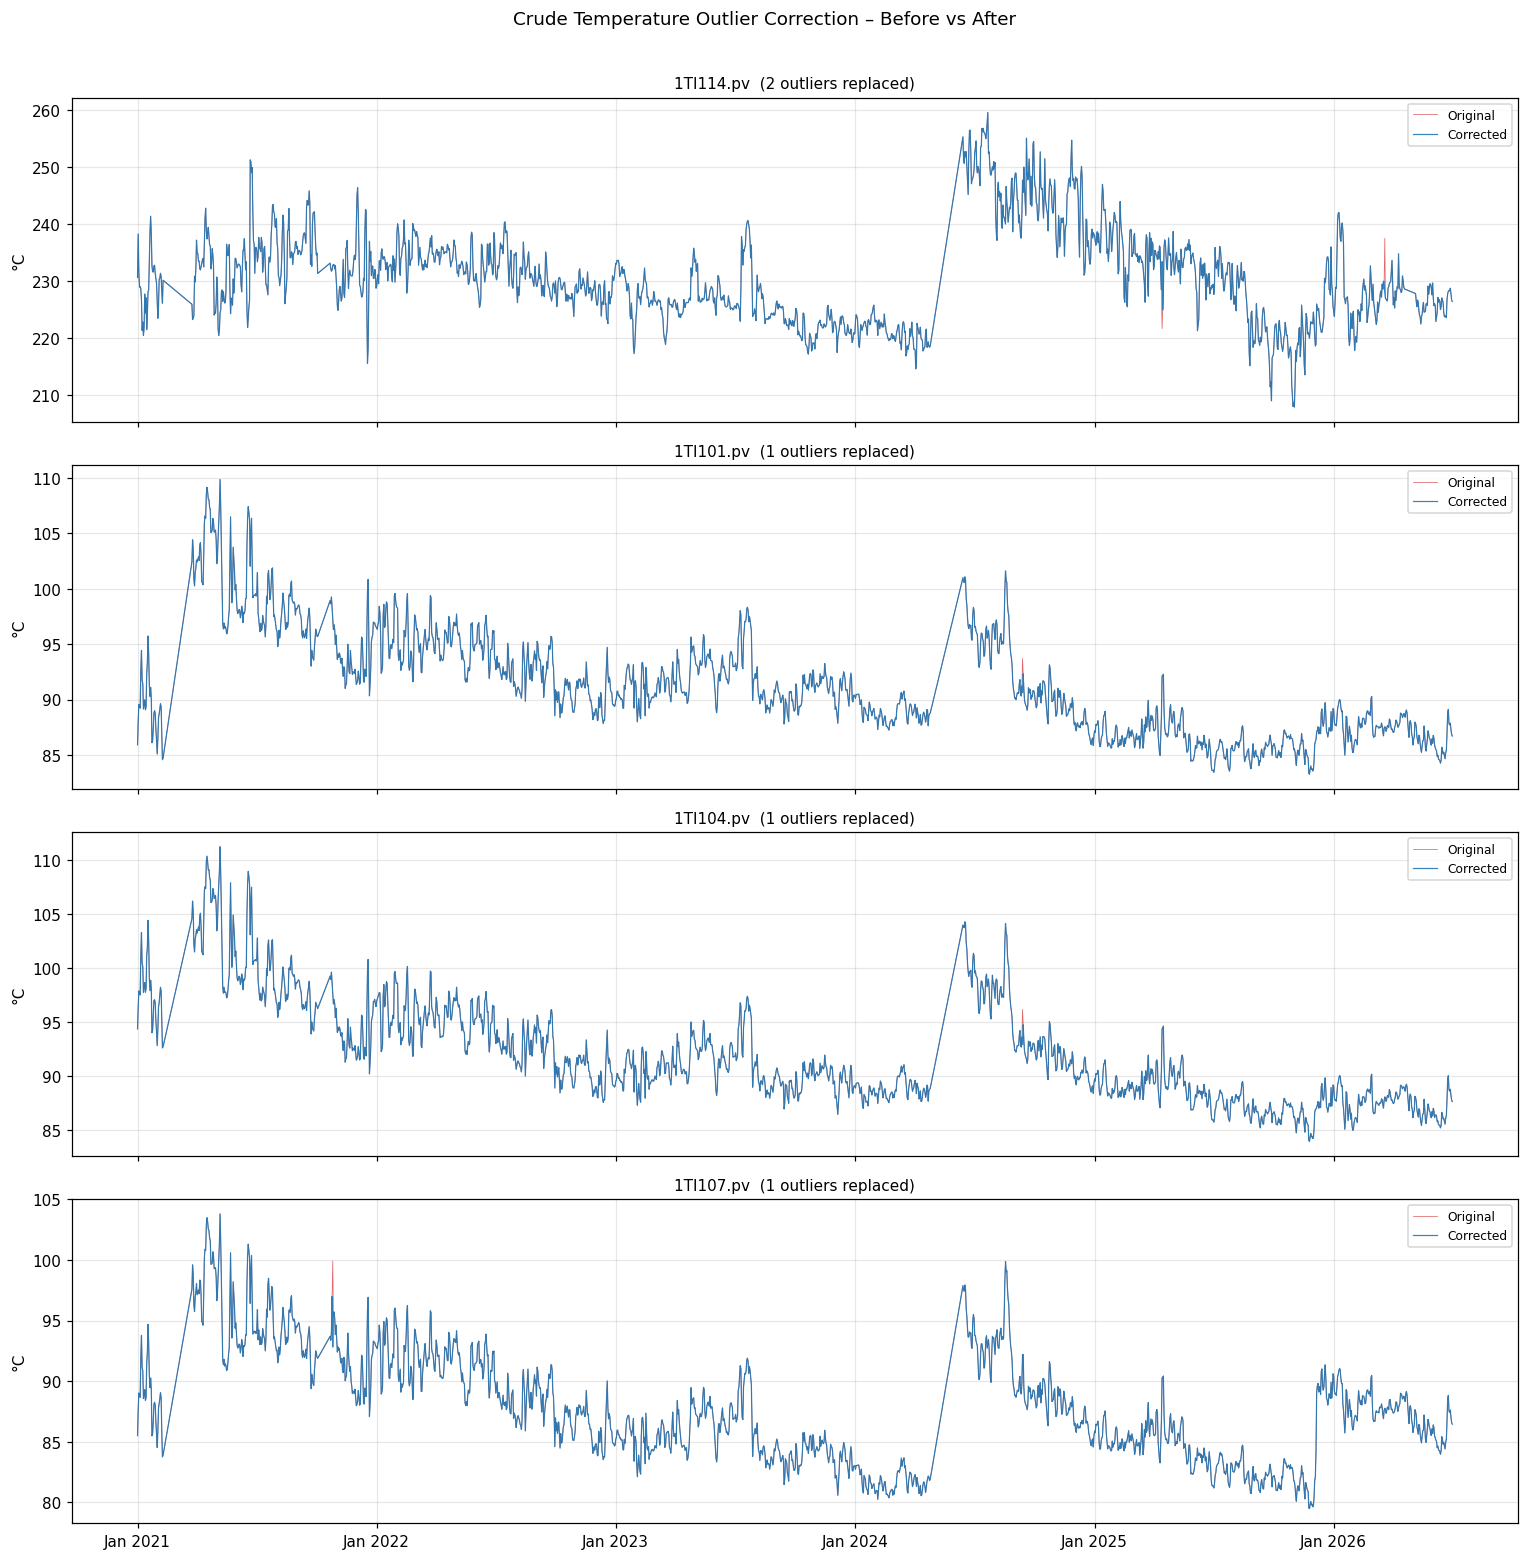

In [5]:
# Show before/after for tags with most outliers (up to 4)
top_tags = out_report.head(4)['tag'].tolist() if len(out_report) >= 1 else []

if top_tags:
    fig, axes = plt.subplots(len(top_tags), 1, figsize=(14, 3.5 * len(top_tags)), sharex=True)
    if len(top_tags) == 1:
        axes = [axes]
    for ax, tag in zip(axes, top_tags):
        ax.plot(df_raw.index, df_raw[tag], lw=0.5, color='tab:red', alpha=0.7, label='Original')
        ax.plot(df.index,     df[tag],     lw=0.8, color='tab:blue', alpha=0.9, label='Corrected')
        n_out = out_report.set_index('tag').loc[tag, 'n_outliers']
        ax.set_title(f'{tag}  ({n_out} outliers replaced)', fontsize=10)
        ax.set_ylabel('°C')
        ax.legend(fontsize=8)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.suptitle('Crude Temperature Outlier Correction – Before vs After', y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'outlier_correction.png', dpi=110, bbox_inches='tight')
    plt.show()
else:
    print('No outliers detected – no plot needed.')

## 3. HX Configuration & Q-based Feature Engineering

**Primary fouling metric: Q duty (cold-side only)**

> `Q_kW = RHO × V_cold × CP × dT_cold / 3600`

Uses only crude-side tags (flow, inlet T, outlet T) — no hot-side needed.

**Charge-normalised duty (for campaign trend analysis):**

> `Q_norm = Q_kW / total_charge_rate`  [kW / (m³/hr)]

Dividing by total plant throughput removes the bulk effect of charge rate
variation, leaving the thermal performance change from fouling as the main signal.

**dT_cold** (crude temperature rise across the HX) is also kept as a secondary
feature — it is proportional to Q_norm at constant charge rate and is the
cleanest cold-side-only indicator when flow data is unavailable (E102, E113A).

In [6]:
def classify_side(items):
    flow = t_in = t_out = None
    unclassified = []
    for tag, label, unit in items:
        ll = label.lower()
        if unit == 'M3/HR':
            flow = tag
        elif unit == 'DEGC':
            if 'inlet' in ll:
                t_in = tag
            elif 'outlet' in ll:
                t_out = tag
            else:
                unclassified.append(tag)
    if t_in is None and unclassified:
        t_in = unclassified[0]
    return flow, t_in, t_out

def parse_hx(cfg):
    cold_flow, cold_in, cold_out = classify_side(cfg['cold'])
    hot_flow,  hot_in,  hot_out  = classify_side(cfg['hot'])
    return dict(cold_flow=cold_flow, cold_in=cold_in, cold_out=cold_out,
                hot_flow=hot_flow,   hot_in=hot_in,   hot_out=hot_out)

streams = {hx: parse_hx(cfg) for hx, cfg in HX_CONFIG.items()}

charge = df[CHARGE_TAG].replace(0, np.nan)   # total crude charge rate (m3/hr)

dT_cold_df = pd.DataFrame(index=df.index)    # crude temperature rise (°C)
duty_df    = pd.DataFrame(index=df.index)    # Q kW  (cold-side calc, where available)
Q_norm_df  = pd.DataFrame(index=df.index)    # Q_kW / charge_rate (normalised)

for hx, s in streams.items():
    if s['cold_in'] and s['cold_out']:
        dT_cold_df[hx] = df[s['cold_out']] - df[s['cold_in']]

    if s['cold_flow'] and s['cold_in'] and s['cold_out']:
        # Preferred: use cold-side flow directly
        Q = RHO_CRUDE * df[s['cold_flow']] * CP_CRUDE * dT_cold_df[hx] / 3600
        duty_df[hx]   = Q
        Q_norm_df[hx] = Q / charge
    elif s['hot_flow'] and s['hot_in'] and s['hot_out']:
        # Fallback: use hot-side flow (Q_hot ≈ Q_cold at steady state)
        dT_hot = df[s['hot_in']] - df[s['hot_out']]
        Q = RHO_CRUDE * df[s['hot_flow']] * CP_CRUDE * dT_hot / 3600
        duty_df[hx]   = Q
        Q_norm_df[hx] = Q / charge
    elif s['cold_in'] and s['cold_out']:
        # No flow tag available – use dT_cold normalised by charge as proxy
        Q_norm_df[hx] = dT_cold_df[hx] / charge * 100   # scale for readability

print('Q duty summary (kW) for HX with cold-side flow:')
duty_df.describe().T[['count','mean','std','min','max']].round(1)

Q duty summary (kW) for HX with cold-side flow:


,count,mean,std,min,max
E101AB,1898.0,5192.9,803.3,3075.2,6845.9
E101CD,1898.0,4245.7,620.9,2156.9,5498.7
E101EF,1898.0,3298.7,1204.4,-39.6,4975.8
E102,1898.0,1019.7,384.7,0.0,2193.5
E103AB,1898.0,6894.4,2899.1,2735.1,12337.9
E104,1898.0,4320.8,750.4,2122.3,7852.1
E105AB,1898.0,6988.5,1060.0,3262.3,9564.2
E106AB,1898.0,4906.1,1850.8,2586.4,8596.8
E107AB,1898.0,2310.3,1077.7,-159.4,10892.9
E108AB,1898.0,1553.4,1108.4,-7047.4,4281.9


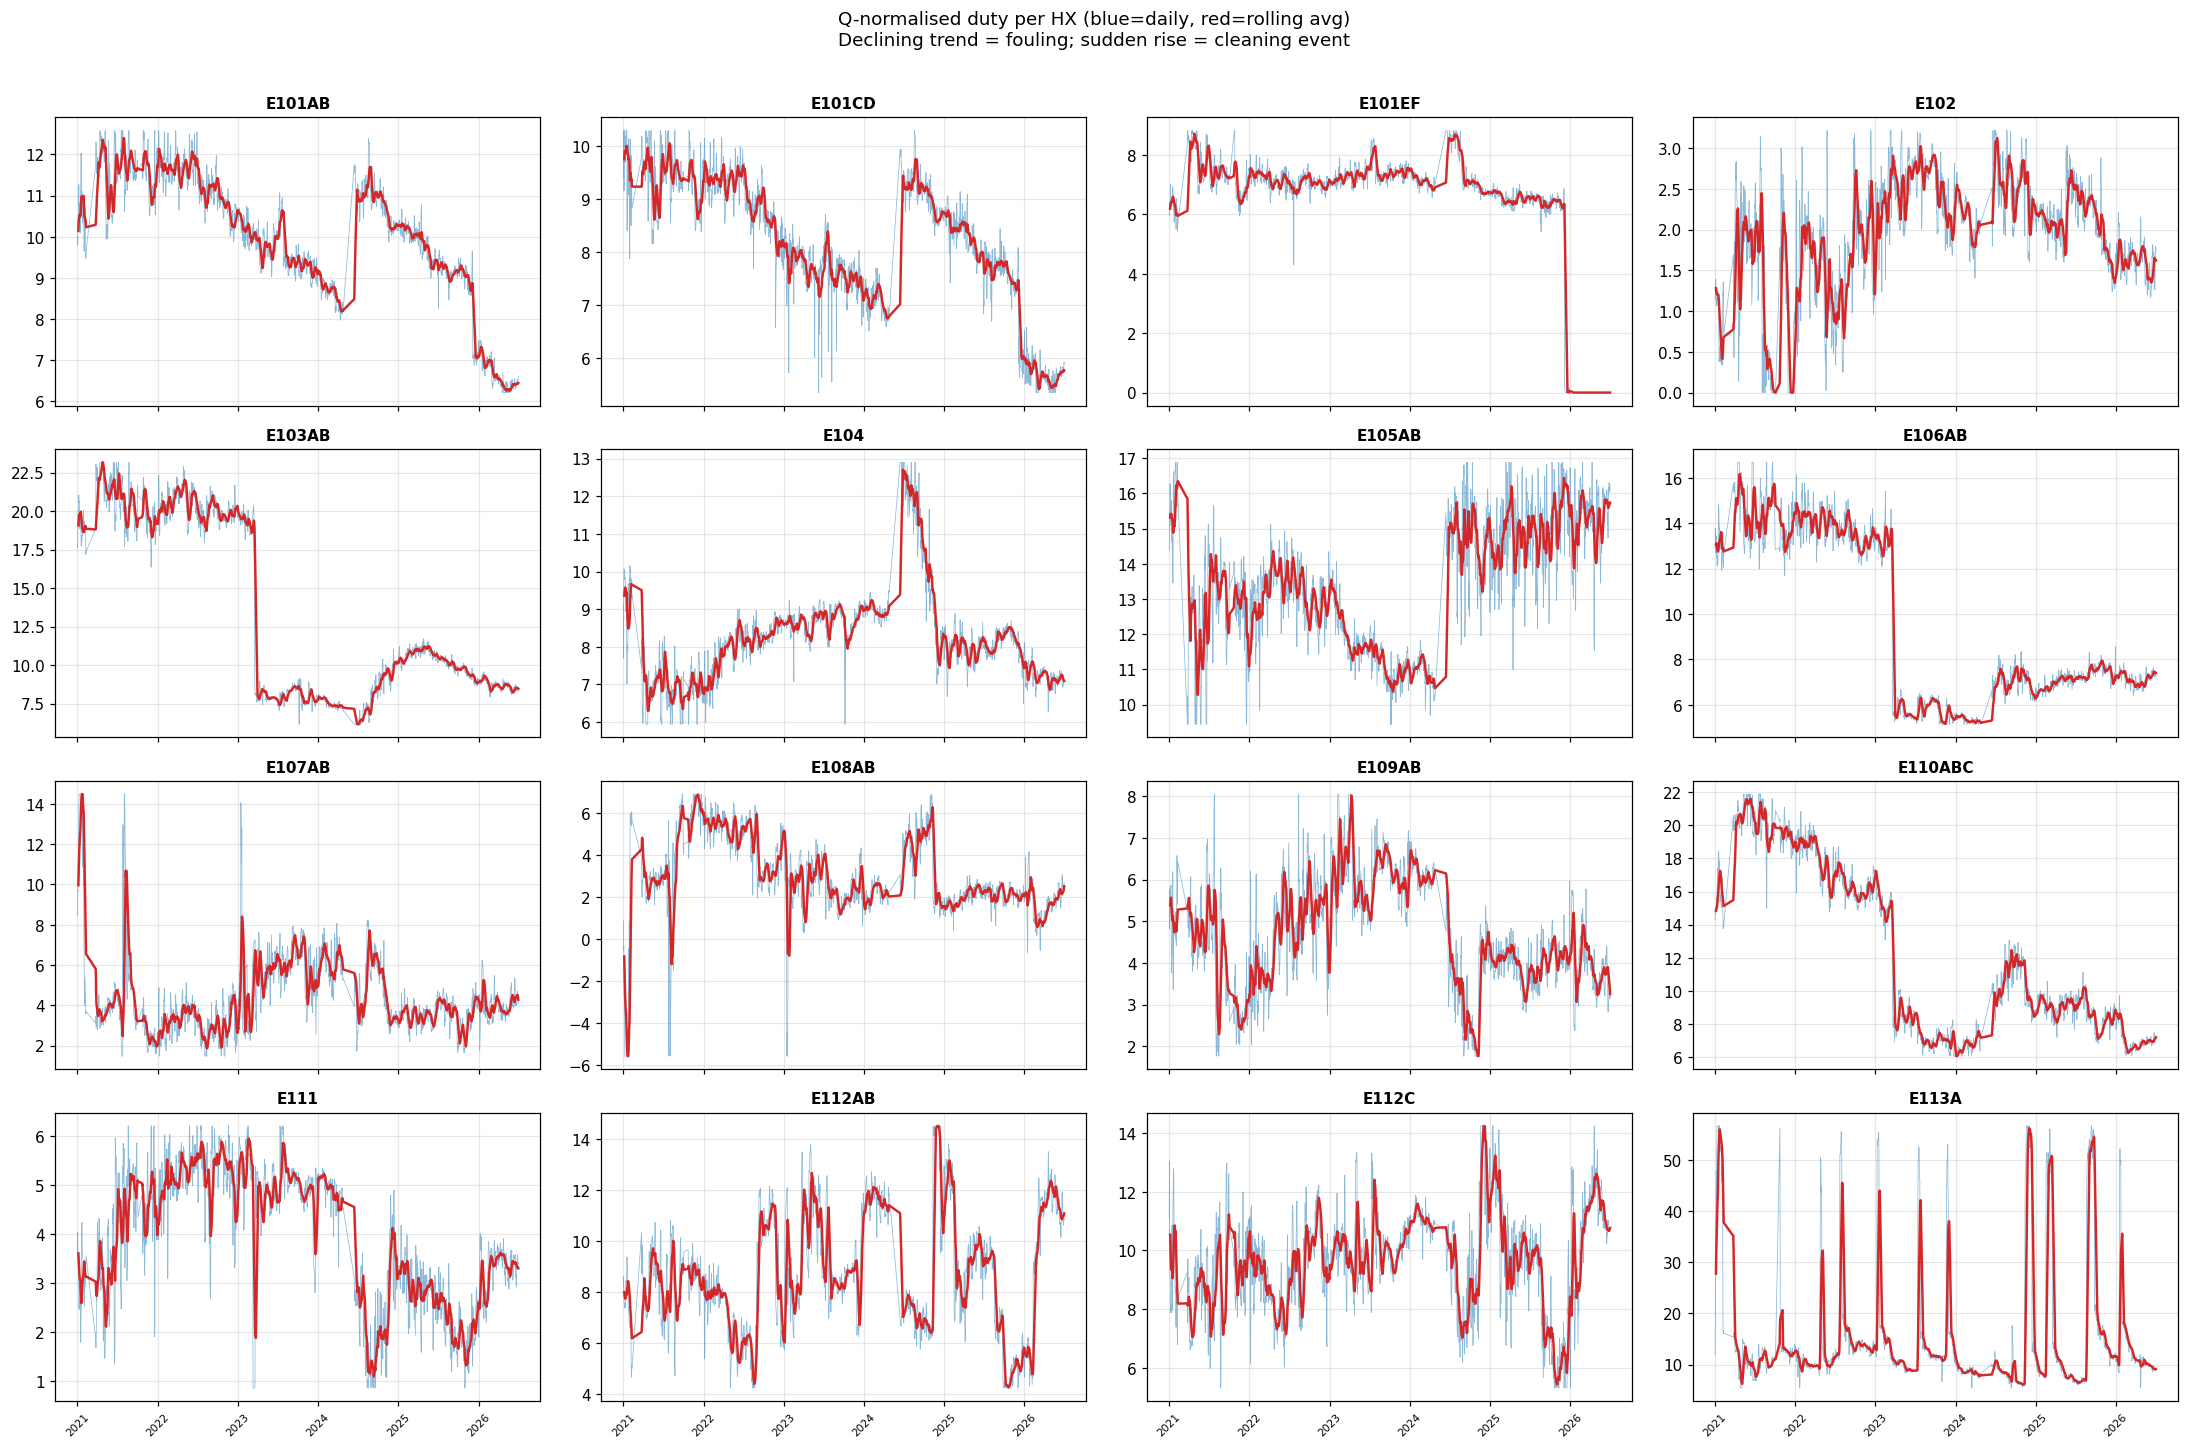

In [7]:
# Plot Q_norm per HX (daily + 14-day rolling) — this is the primary fouling indicator
fig, axes = plt.subplots(4, 4, figsize=(20, 13), sharex=True)
axes = axes.flatten()

for i, hx in enumerate(HX_CONFIG.keys()):
    ax = axes[i]
    if hx in Q_norm_df.columns:
        s = Q_norm_df[hx].clip(
            Q_norm_df[hx].quantile(0.01),
            Q_norm_df[hx].quantile(0.99)
        )
        ax.plot(s.index, s, lw=0.5, color='tab:blue', alpha=0.5, label='daily')
        ax.plot(s.index, s.rolling(ROLL_SMOOTH, min_periods=5).mean(),
                lw=1.6, color='tab:red', label=f'{ROLL_SMOOTH}d avg')
    ax.set_title(hx, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)

for j in range(len(HX_CONFIG), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Q-normalised duty per HX (blue=daily, red=rolling avg)\n'
             'Declining trend = fouling; sudden rise = cleaning event',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'Q_norm_all_hx.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. TAM Segment Detection + Q-based Campaign Inference

Same two-layer logic as before, but now based on **Q_norm jumps** instead of eps jumps:
- Global TAM boundaries from date gaps in the cleaned CSV
- Local per-HX clean events: sudden upward step in smoothed Q_norm
  (> 2.5 × std of daily Q change) within each global segment

In [8]:
day_gap = df.index.to_series().diff().dt.days
seg_id  = (day_gap > 1).cumsum()
segments = [(grp.min(), grp.max())
            for _, grp in df.index.to_series().groupby(seg_id)]

print(f'{len(segments)} global TAM segment(s):')
for s in segments:
    print(f'  {s[0].date()} -> {s[1].date()}  ({(s[1]-s[0]).days} days)')

4 global TAM segment(s):
  2021-01-01 -> 2021-02-09  (39 days)
  2021-03-25 -> 2021-10-03  (192 days)
  2021-10-22 -> 2024-04-25  (916 days)
  2024-06-14 -> 2026-07-01  (747 days)


In [9]:
def detect_campaigns_Q(series, seg_start, seg_end, min_days=MIN_CAMPAIGN_DAYS):
    """Detect cleaning events as sudden upward jumps in smoothed Q."""
    s = series.loc[seg_start:seg_end].dropna()
    if len(s) < min_days:
        return [(seg_start, seg_end)]

    smooth = s.rolling(7, min_periods=3).mean()
    delta  = smooth.diff()
    thresh = delta.std(skipna=True) * 2.5

    if not np.isfinite(thresh) or thresh <= 0:
        return [(seg_start, seg_end)]

    # Upward jump in Q = cleaning event (opposite direction vs eps drop detection)
    jump_days = sorted(delta.index[delta > thresh])
    boundaries, last = [seg_start], None
    for d in jump_days:
        if last is None or (d - last).days > 5:
            boundaries.append(d)
        last = d
    boundaries.append(seg_end + pd.Timedelta(days=1))
    boundaries = sorted(set(boundaries))

    campaigns = []
    for i in range(len(boundaries) - 1):
        c_start = boundaries[i]
        c_end   = boundaries[i + 1] - pd.Timedelta(days=1)
        if c_end >= c_start and (c_end - c_start).days + 1 >= min_days:
            campaigns.append((c_start, c_end))

    return campaigns if campaigns else [(seg_start, seg_end)]


all_campaigns = {}
for hx in Q_norm_df.columns:
    camps = []
    for seg_start, seg_end in segments:
        camps.extend(detect_campaigns_Q(Q_norm_df[hx], seg_start, seg_end))
    all_campaigns[hx] = camps

n_camp = {hx: len(c) for hx, c in all_campaigns.items()}
print('Campaigns detected per HX (based on Q_norm jumps):')
print(pd.Series(n_camp).sort_values(ascending=False))

Campaigns detected per HX (based on Q_norm jumps):
E101CD     17
E109AB     16
E113A      15
E105AB     14
E102       13
E112AB     13
E101AB     13
E112C      12
E110ABC    11
E106AB     11
E103AB     11
E104       11
E111       11
E107AB     10
E108AB      9
E101EF      7
dtype: int64


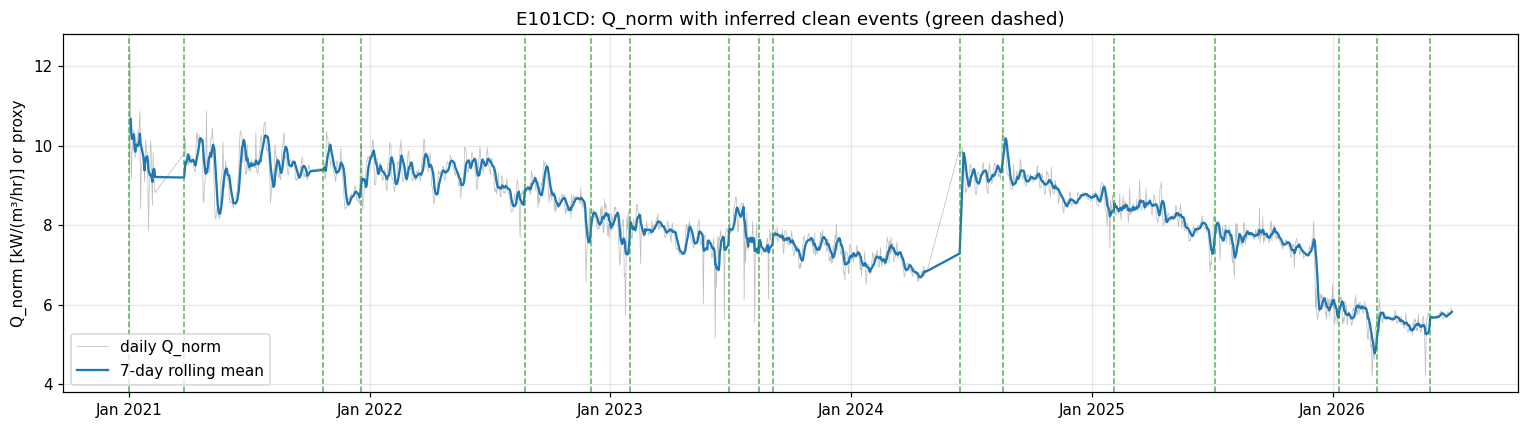

In [10]:
# Show campaign boundaries on the HX with most detected events
example_hx = pd.Series(n_camp).idxmax()

fig, ax = plt.subplots(figsize=(14, 4))
q = Q_norm_df[example_hx]
ax.plot(q.index, q, lw=0.5, color='gray', alpha=0.5, label='daily Q_norm')
ax.plot(q.index, q.rolling(7, min_periods=3).mean(),
        lw=1.5, color='tab:blue', label='7-day rolling mean')
for c_start, c_end in all_campaigns[example_hx]:
    ax.axvline(c_start, color='tab:green', ls='--', lw=1, alpha=0.8)
ax.set_title(f'{example_hx}: Q_norm with inferred clean events (green dashed)')
ax.set_ylabel('Q_norm [kW/(m³/hr)] or proxy')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / f'Q_campaigns_{example_hx}.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Q Fouling-Rate Ranking

For each campaign, fit a linear trend to `Q_norm` vs days-since-clean.
The slope is the **fouling rate** — how fast duty is declining.

- Negative slope = Q declining = fouling progressing
- The more negative the median slope, the faster the HX fouls

The slope is also expressed as **% Q-drop per 30 days** relative to the
campaign-start baseline to make it comparable across HX of different sizes.

In [11]:
fouling_rows = []
for hx, camps in all_campaigns.items():
    slopes, pct_drops = [], []
    for c_start, c_end in camps:
        s = Q_norm_df.loc[c_start:c_end, hx].dropna()
        if len(s) < 10:
            continue
        x = (s.index - s.index[0]).days.values.astype(float)
        slope, intercept = np.polyfit(x, s.values, 1)
        baseline = intercept  # Q_norm at day 0 of campaign
        slopes.append(slope)
        if baseline and abs(baseline) > 1e-6:
            pct_drops.append(slope / abs(baseline) * 30 * 100)  # % per 30 days

    if slopes:
        fouling_rows.append({
            'HX': hx,
            'n_campaigns': len(slopes),
            'median_Q_slope': np.median(slopes),
            'median_pct_drop_per_30d': np.median(pct_drops) if pct_drops else np.nan,
            'mean_Q_norm': Q_norm_df[hx].mean(),
        })

fouling_rank = (pd.DataFrame(fouling_rows)
                .sort_values('median_Q_slope')
                .reset_index(drop=True))

print('Q Fouling Rate Ranking (most negative slope = fouls fastest):')
fouling_rank.round(5)

Q Fouling Rate Ranking (most negative slope = fouls fastest):


,HX,n_campaigns,median_Q_slope,median_pct_drop_per_30d,mean_Q_norm
0,E113A,15,-0.14991,-16.05610,15.04539
1,E103AB,11,-0.01641,-2.72372,13.33507
2,E112AB,13,-0.01504,-4.57009,8.75010
3,E110ABC,11,-0.01463,-2.58257,12.09822
4,E112C,12,-0.01312,-3.97727,9.62558
5,E101AB,13,-0.01098,-3.26265,9.98811
6,E101EF,7,-0.00639,-2.30867,6.35026
7,E101CD,17,-0.00583,-2.01982,8.16992
8,E102,13,-0.00511,-6.67793,1.94483
9,E105AB,14,-0.00478,-1.08926,13.40298


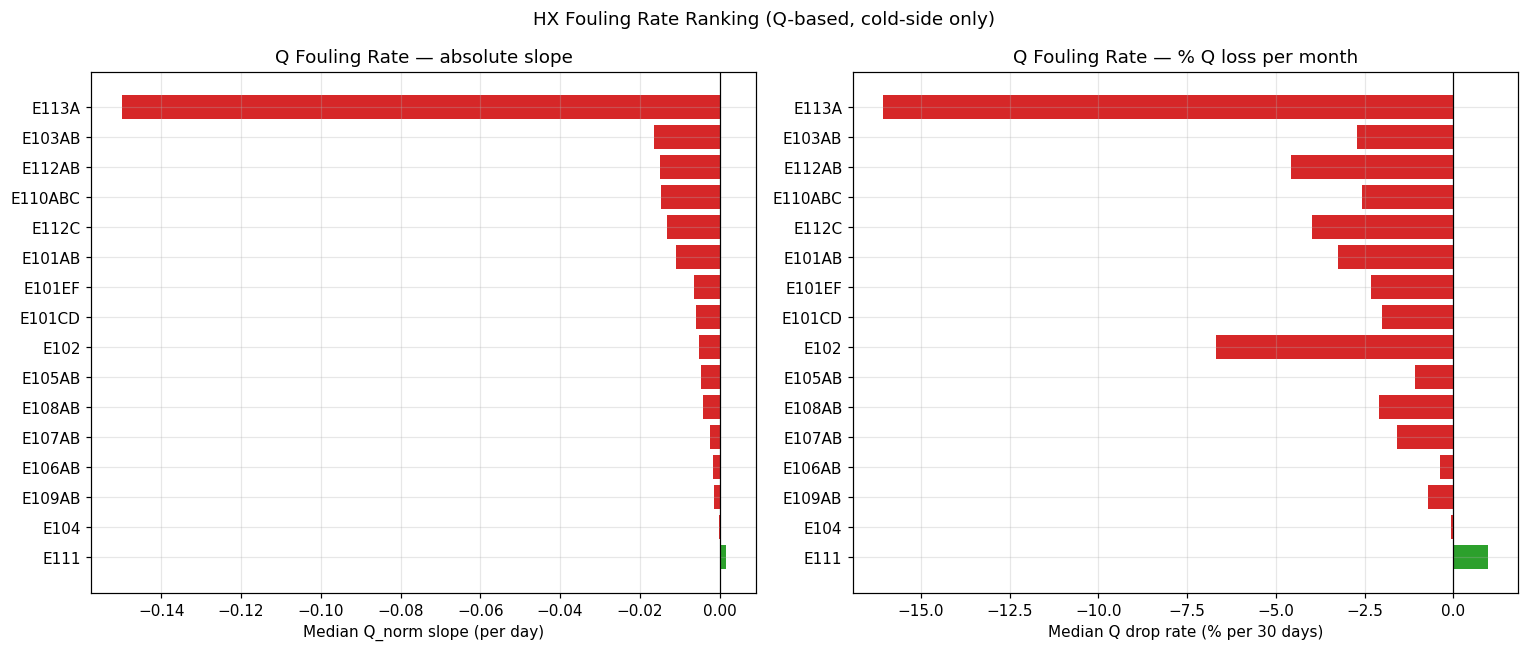

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: absolute slope
colors = ['tab:red' if v < 0 else 'tab:green'
          for v in fouling_rank['median_Q_slope']]
axes[0].barh(fouling_rank['HX'], fouling_rank['median_Q_slope'], color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Median Q_norm slope (per day)')
axes[0].set_title('Q Fouling Rate — absolute slope')
axes[0].invert_yaxis()

# Right: % Q drop per 30 days
fr2 = fouling_rank.dropna(subset=['median_pct_drop_per_30d']).copy()
colors2 = ['tab:red' if v < 0 else 'tab:green'
           for v in fr2['median_pct_drop_per_30d']]
axes[1].barh(fr2['HX'], fr2['median_pct_drop_per_30d'], color=colors2)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Median Q drop rate (% per 30 days)')
axes[1].set_title('Q Fouling Rate — % Q loss per month')
axes[1].invert_yaxis()

plt.suptitle('HX Fouling Rate Ranking (Q-based, cold-side only)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'Q_fouling_rate_ranking.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Q vs CIT Relationship Analysis

To determine **which HX cleaning gives the most CIT back**, we analyse the
statistical relationship between each HX's Q_norm and CIT (`1TI116.pv`).

Two views:
1. **Pearson correlation** — linear strength of the Q–CIT relationship over the full dataset
2. **Rolling 90-day correlation** — how the relationship evolves over time
   (a HX whose Q-CIT correlation strengthens over time is increasingly dominant)

HX with **high positive Q-CIT correlation + high fouling rate** = top priority to clean.

In [13]:
cit = df[TARGET_TAG]

# Full-period Pearson correlation of each HX's Q_norm with CIT
corr_rows = []
for hx in Q_norm_df.columns:
    joint = pd.concat([Q_norm_df[hx], cit], axis=1).dropna()
    if len(joint) < 30:
        continue
    r = joint.iloc[:, 0].corr(joint.iloc[:, 1])
    corr_rows.append({'HX': hx, 'Q_CIT_corr': round(r, 4)})

corr_df = (pd.DataFrame(corr_rows)
           .sort_values('Q_CIT_corr', ascending=False)
           .reset_index(drop=True))
print('Q_norm – CIT Pearson correlation (full period):')
corr_df

Q_norm – CIT Pearson correlation (full period):


,HX,Q_CIT_corr
0,E105AB,0.4066
1,E101CD,0.3290
2,E101AB,0.2858
3,E110ABC,0.2273
4,E106AB,0.1457
5,E108AB,0.1297
6,E103AB,0.0982
7,E104,0.0821
8,E102,0.0577
9,E101EF,0.0145


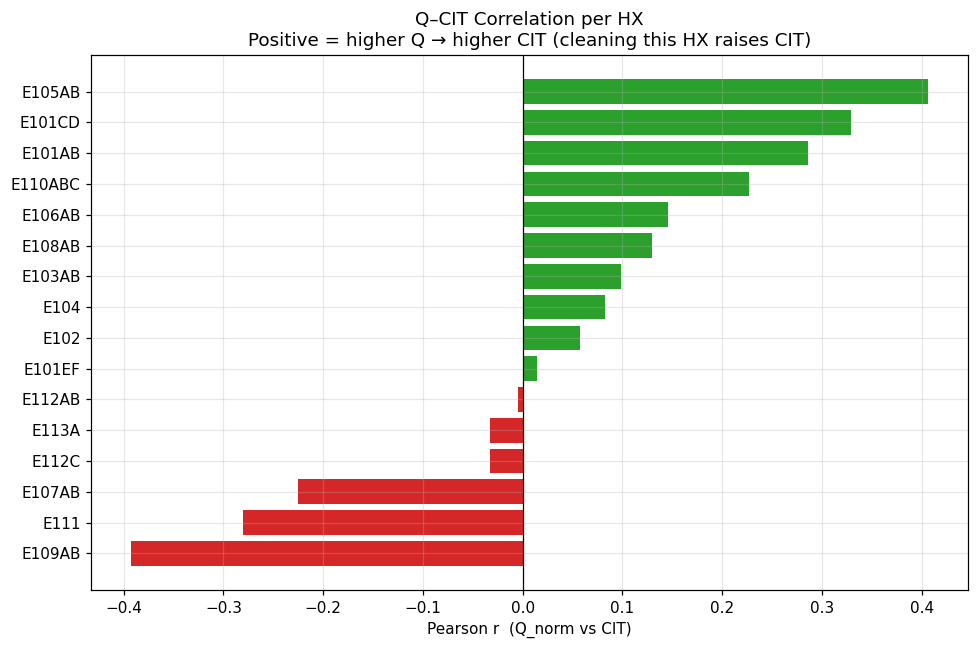

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['tab:green' if v > 0 else 'tab:red' for v in corr_df['Q_CIT_corr']]
ax.barh(corr_df['HX'], corr_df['Q_CIT_corr'], color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r  (Q_norm vs CIT)')
ax.set_title('Q–CIT Correlation per HX\n'
             'Positive = higher Q → higher CIT (cleaning this HX raises CIT)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'Q_CIT_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

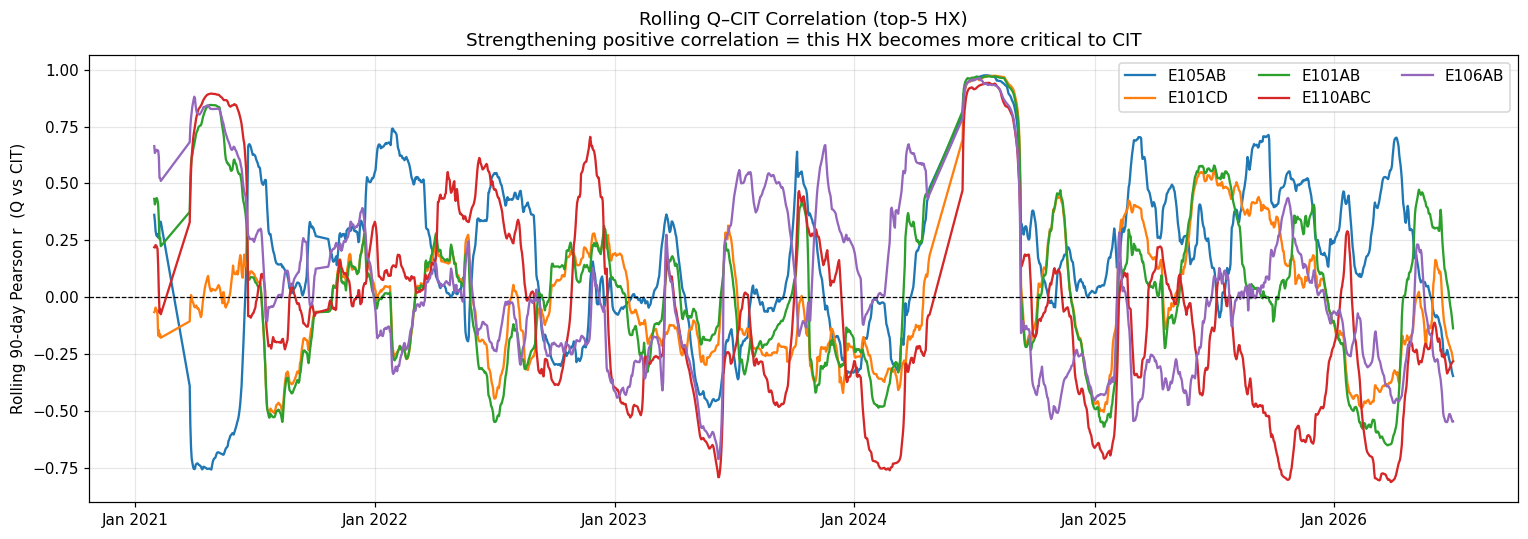

In [15]:
# Rolling 90-day Q–CIT correlation for the top-5 correlated HX
top5_hx = corr_df.head(5)['HX'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
for hx in top5_hx:
    joint = pd.concat([Q_norm_df[hx], cit], axis=1).dropna()
    roll_r = joint.iloc[:, 0].rolling(90, min_periods=30).corr(joint.iloc[:, 1])
    ax.plot(roll_r.index, roll_r, lw=1.5, label=hx)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_ylabel('Rolling 90-day Pearson r  (Q vs CIT)')
ax.set_title('Rolling Q–CIT Correlation (top-5 HX)\n'
             'Strengthening positive correlation = this HX becomes more critical to CIT')
ax.legend(ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'Q_CIT_rolling_corr.png', dpi=110, bbox_inches='tight')
plt.show()

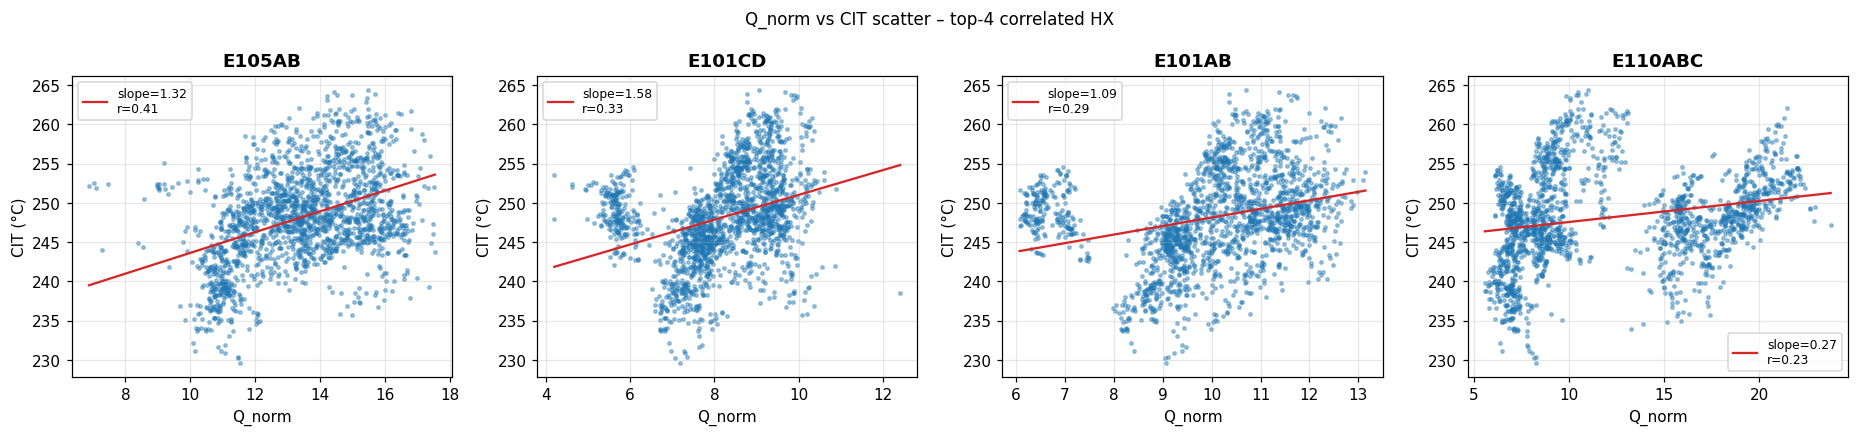

In [16]:
# Scatter Q_norm vs CIT for top-4 correlated HX  + linear trend line
top4 = corr_df.head(4)['HX'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, hx in zip(axes, top4):
    joint = pd.concat([Q_norm_df[hx].rename('Q'), cit.rename('CIT')], axis=1).dropna()
    ax.scatter(joint['Q'], joint['CIT'], s=5, alpha=0.4, color='tab:blue')
    m, b = np.polyfit(joint['Q'], joint['CIT'], 1)
    xr = np.linspace(joint['Q'].min(), joint['Q'].max(), 100)
    ax.plot(xr, m * xr + b, color='tab:red', lw=1.5,
            label=f'slope={m:.2f}\nr={joint["Q"].corr(joint["CIT"]):.2f}')
    ax.set_xlabel('Q_norm')
    ax.set_ylabel('CIT (°C)')
    ax.set_title(hx, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Q_norm vs CIT scatter – top-4 correlated HX', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'Q_CIT_scatter.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Cleaning Recommendation (Q-based Trigger)

For each HX's **current campaign**, the Q baseline is the 90th percentile of
the first 10% of campaign days (the "fresh" performance after a clean).

Cleaning is triggered when Q_norm drops more than **12.5%** from that baseline
(consistent with the 10-15% threshold in the Cleaning & Problem Control Plan).
If already past trigger, the HX is flagged immediately.

In [17]:
last_date = df.index.max()
reco_rows = []

for hx, camps in all_campaigns.items():
    c_start, c_end = camps[-1]
    s = Q_norm_df.loc[c_start:c_end, hx].dropna()
    if len(s) < 10:
        continue

    x = (s.index - s.index[0]).days.values.astype(float)
    y = s.values
    slope, intercept = np.polyfit(x, y, 1)

    # Baseline: high-percentile of early campaign (first 10% of days, minimum 5)
    n_early  = max(5, len(y) // 10)
    baseline = np.percentile(y[:n_early], 90)
    current  = y[-1]

    drop_frac = (baseline - current) / abs(baseline) if abs(baseline) > 1e-6 else np.nan
    past_trigger = bool(pd.notna(drop_frac) and drop_frac >= TRIGGER_DROP_FRAC)

    if past_trigger:
        action = 'Clean now (past trigger)'
    elif slope >= -1e-6:
        action = 'Stable / monitor'
    else:
        target_Q = baseline * (1 - TRIGGER_DROP_FRAC)
        days_to_trigger = (target_Q - intercept) / slope
        eta = c_start + pd.Timedelta(days=days_to_trigger)
        horizon_days = (eta - last_date).days
        if 0 <= horizon_days <= 1095:
            action = eta.date().isoformat()
        else:
            action = 'Stable / long horizon (>3y)'

    reco_rows.append({
        'HX'                 : hx,
        'campaign_start'     : c_start.date(),
        'days_in_campaign'   : (last_date - c_start).days,
        'baseline_Q_norm'    : round(baseline, 4),
        'current_Q_norm'     : round(current, 4),
        'Q_drop_%'           : round(drop_frac * 100, 1) if pd.notna(drop_frac) else np.nan,
        'past_trigger'       : past_trigger,
        'recommended_action' : action,
    })

cleaning_reco = (pd.DataFrame(reco_rows)
                 .sort_values('Q_drop_%', ascending=False)
                 .reset_index(drop=True))
cleaning_reco

,HX,campaign_start,days_in_campaign,baseline_Q_norm,current_Q_norm,Q_drop_%,past_trigger,recommended_action
0,E101EF,2024-06-14,747,8.9390,0.0000,100.0,True,Clean now (past trigger)
1,E113A,2026-01-16,166,50.8275,9.0124,82.3,True,Clean now (past trigger)
2,E102,2025-06-01,395,2.7897,1.7226,38.3,True,Clean now (past trigger)
3,E110ABC,2025-07-02,364,10.5598,7.1082,32.7,True,Clean now (past trigger)
4,E109AB,2026-03-14,109,4.7504,3.2059,32.5,True,Clean now (past trigger)
5,E108AB,2026-01-19,163,3.9230,2.6766,31.8,True,Clean now (past trigger)
6,E107AB,2026-01-13,169,6.0304,4.1427,31.3,True,Clean now (past trigger)
7,E101AB,2025-07-09,357,9.4451,6.5946,30.2,True,Clean now (past trigger)
8,E104,2024-10-24,615,9.7585,7.1018,27.2,True,Clean now (past trigger)
9,E103AB,2024-12-04,574,10.6095,8.3093,21.7,True,Clean now (past trigger)


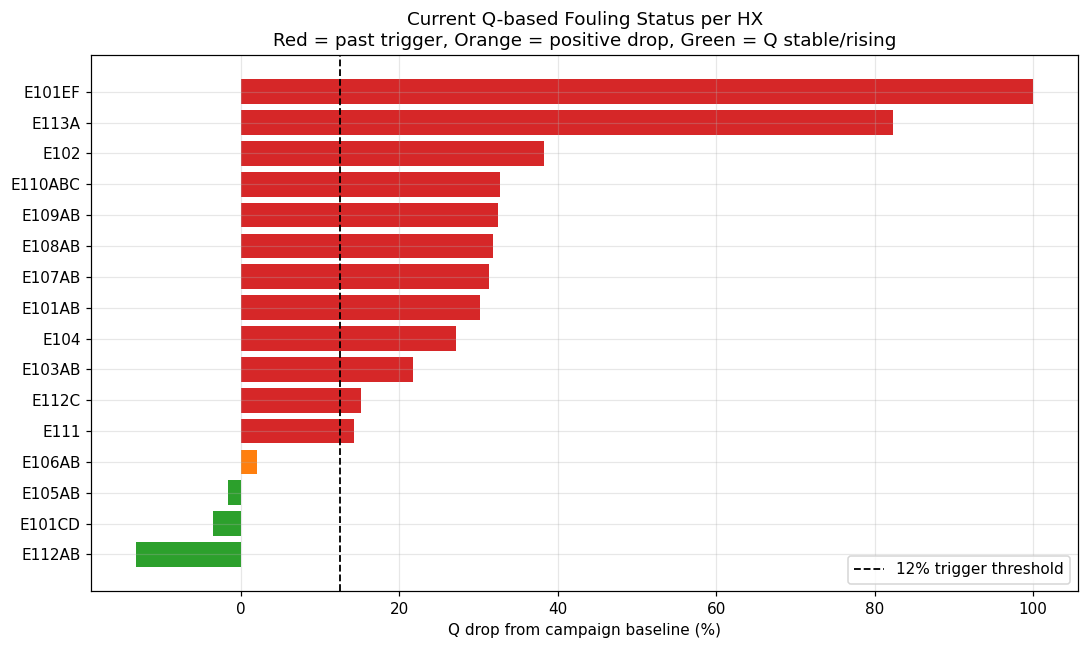

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
reco_plot = cleaning_reco.dropna(subset=['Q_drop_%']).set_index('HX')
bar_c = ['tab:red' if v else 'tab:orange' if d > 0 else 'tab:green'
          for v, d in zip(reco_plot['past_trigger'], reco_plot['Q_drop_%'])]
ax.barh(reco_plot.index, reco_plot['Q_drop_%'], color=bar_c)
ax.axvline(TRIGGER_DROP_FRAC * 100, color='black', ls='--', lw=1.2,
           label=f'{TRIGGER_DROP_FRAC*100:.0f}% trigger threshold')
ax.set_xlabel('Q drop from campaign baseline (%)')
ax.set_title('Current Q-based Fouling Status per HX\n'
             'Red = past trigger, Orange = positive drop, Green = Q stable/rising')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'Q_cleaning_recommendation.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Leak-free Feature Matrix for CIT Prediction

**E113A** — cold-side outlet `1TI116.pv` IS the target (CIT). Any feature that
uses this tag directly (dT_cold, Q_kW) would leak the answer into the model.
From E113A we therefore use only:
- `E113A_cold_in` = `1TI115.pv` (crude temp just before the final HX)
- `E113A_dT_hot` = residue side temperature drop (no CIT in formula)

Features used: `Q_norm`, `dT_cold`, `duty_kW` for all non-E113A exchangers;
plus `total_charge` and `flue_O2` as plant-state context.

In [19]:
feat = pd.DataFrame(index=df.index)

for hx, s in streams.items():
    leaky = (hx == LEAK_TARGET_HX)
    if not leaky:
        if hx in Q_norm_df.columns:
            feat[f'{hx}_Q_norm'] = Q_norm_df[hx]
        if hx in dT_cold_df.columns:
            feat[f'{hx}_dT_cold'] = dT_cold_df[hx]
        if hx in duty_df.columns:
            feat[f'{hx}_duty_kW'] = duty_df[hx]
    # Hot-side dT does NOT use CIT, so safe to include even for E113A
    if s['hot_in'] and s['hot_out']:
        feat[f'{hx}_dT_hot'] = df[s['hot_in']] - df[s['hot_out']]
    if leaky:
        feat[f'{hx}_cold_in'] = df[s['cold_in']]   # 1TI115.pv

feat['total_charge'] = df[CHARGE_TAG]
feat['flue_O2']      = df[O2_TAG]

target = df[TARGET_TAG]

# Sanity check – no leakage
leak_check = [c for c in feat.columns
              if f'{LEAK_TARGET_HX}_Q_norm'   in c or
                 f'{LEAK_TARGET_HX}_dT_cold'  in c or
                 f'{LEAK_TARGET_HX}_duty_kW'  in c]
assert TARGET_TAG not in feat.columns and not leak_check, f'Target leakage: {leak_check}'

data = feat.copy()
data['CIT'] = target
data = data.dropna()

print('Feature matrix shape (after dropna):', data.shape)
print('No target-leakage columns – OK.')

X = data.drop(columns=['CIT'])
y = data['CIT']

Feature matrix shape (after dropna): (1898, 65)
No target-leakage columns – OK.


Train: 2021-01-01 -> 2025-06-16  (n=1518)
Test:  2025-06-17 -> 2026-07-01  (n=380)


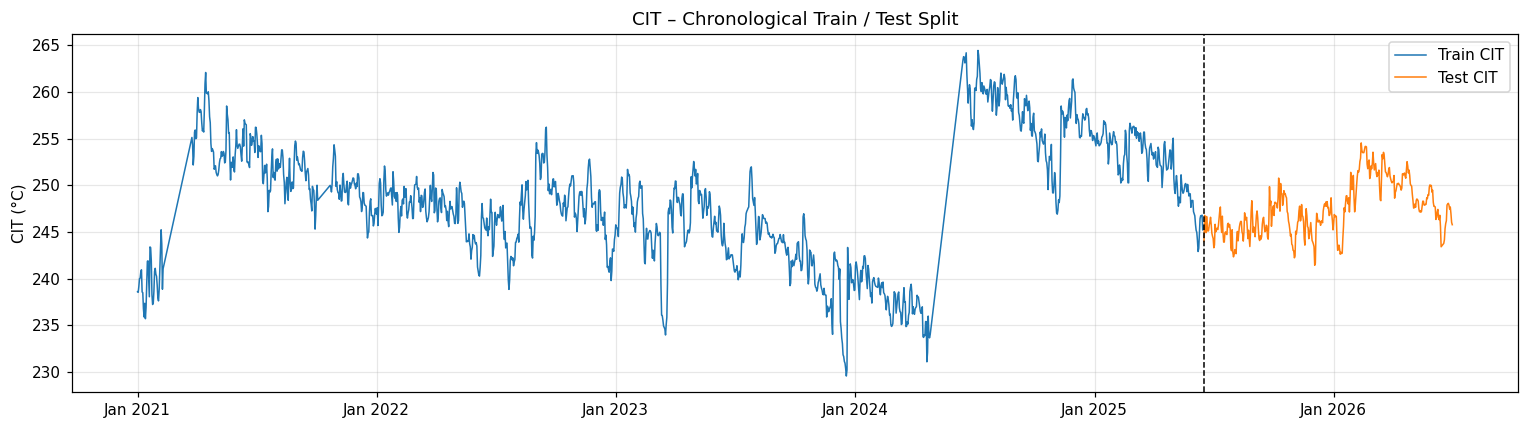

In [20]:
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.index.min().date()} -> {X_train.index.max().date()}  (n={len(X_train)})')
print(f'Test:  {X_test.index.min().date()} -> {X_test.index.max().date()}  (n={len(X_test)})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_train.index, y_train, lw=1, color='tab:blue', label='Train CIT')
ax.plot(y_test.index,  y_test,  lw=1, color='tab:orange', label='Test CIT')
ax.axvline(X_test.index[0], color='black', ls='--', lw=1)
ax.set_ylabel('CIT (°C)')
ax.set_title('CIT – Chronological Train / Test Split')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

## 9. Model Comparison

> ⚠️ **Honest-validation note (systematic audit):** the CIT point model in sections 9–10 was later stress-tested with **walk-forward cross-validation** in `6a` and found to **lose to a simple persistence baseline (CIT_today = CIT_yesterday) on every fold** — its single-split R²≈0.82 is an artifact of one chronological split, not out-of-sample skill. So read sections 9–11 as **associative attribution only** (which HX *co-varies* with CIT), **not** as a validated forecaster. This is exactly why the deployed cleaning ranking in `2d` uses the **measured Q-duty shortfall** as its primary consequence signal, with this CIT-model gain kept only as a down-weighted (0.25) secondary.

In [21]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb

sk_models = {
    'Ridge'       : Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42),
    'XGBoost'     : xgb.XGBRegressor(n_estimators=300, max_depth=4,
                                      learning_rate=0.05, random_state=42),
    'AdaBoost'    : AdaBoostRegressor(n_estimators=100, random_state=42),
    'Bagging'     : BaggingRegressor(n_estimators=100, random_state=42),
}

def eval_predictions(name, y_true, pred):
    return {
        'model'      : name,
        'R2'         : r2_score(y_true, pred),
        'MAE'        : mean_absolute_error(y_true, pred),
        'RMSE'       : np.sqrt(mean_squared_error(y_true, pred)),
        'within_5C_%' : (np.abs(pred - y_true) <= 5).mean() * 100,
        'within_10C_%': (np.abs(pred - y_true) <= 10).mean() * 100,
    }

results, fitted, predictions = [], {}, {}
for name, m in sk_models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results.append(eval_predictions(name, y_test.values, pred))
    fitted[name]      = m
    predictions[name] = pred

print('Trained sklearn models:', list(sk_models.keys()))

Trained sklearn models: ['Ridge', 'RandomForest', 'XGBoost', 'AdaBoost', 'Bagging']


In [22]:
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

ENROL = 7
sx = StandardScaler().fit(X_train)
sy = StandardScaler().fit(y_train.values.reshape(-1, 1))
Xtr_s = sx.transform(X_train)
Xte_s = sx.transform(X_test)
ytr_s = sy.transform(y_train.values.reshape(-1, 1)).flatten()
yte_s = sy.transform(y_test.values.reshape(-1, 1)).flatten()

def make_windows(arr, tgt, window):
    Xw, yw = [], []
    for i in range(window, len(arr)):
        Xw.append(arr[i - window:i])
        yw.append(tgt[i])
    return np.array(Xw), np.array(yw)

Xtr_w, ytr_w = make_windows(Xtr_s, ytr_s, ENROL)
Xte_w, yte_w = make_windows(Xte_s, yte_s, ENROL)

lstm = keras.Sequential([
    layers.Input(shape=(ENROL, Xtr_w.shape[2])),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])
lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss='mse')
es = keras.callbacks.EarlyStopping(monitor='loss', patience=20,
                                    restore_best_weights=True)
lstm.fit(Xtr_w, ytr_w, epochs=200, batch_size=32, callbacks=[es], verbose=0)

pred_lstm_s  = lstm.predict(Xte_w, verbose=0).flatten()
pred_lstm    = sy.inverse_transform(pred_lstm_s.reshape(-1, 1)).flatten()
y_test_lstm  = sy.inverse_transform(yte_w.reshape(-1, 1)).flatten()

results.append(eval_predictions('LSTM', y_test_lstm, pred_lstm))
print(f'LSTM trained (window = {ENROL} days)')

LSTM trained (window = 7 days)


In [23]:
results_df = (pd.DataFrame(results)
              .sort_values('within_10C_%', ascending=False)
              .reset_index(drop=True))
print('Primary metric: within_10C_% (project acceptance criterion)')
results_df

Primary metric: within_10C_% (project acceptance criterion)


,model,R2,MAE,RMSE,within_5C_%,within_10C_%
0,AdaBoost,-0.393001,2.858849,3.326521,90.000000,100.000000
1,XGBoost,-1.495924,3.799867,4.452770,67.368421,99.736842
2,LSTM,-1.174334,3.304463,4.172329,76.675603,99.463807
3,Bagging,-0.654563,2.968923,3.625402,84.473684,99.210526
4,RandomForest,-0.701394,3.012129,3.676351,84.473684,98.684211
5,Ridge,-0.859180,2.897035,3.843043,84.473684,98.421053


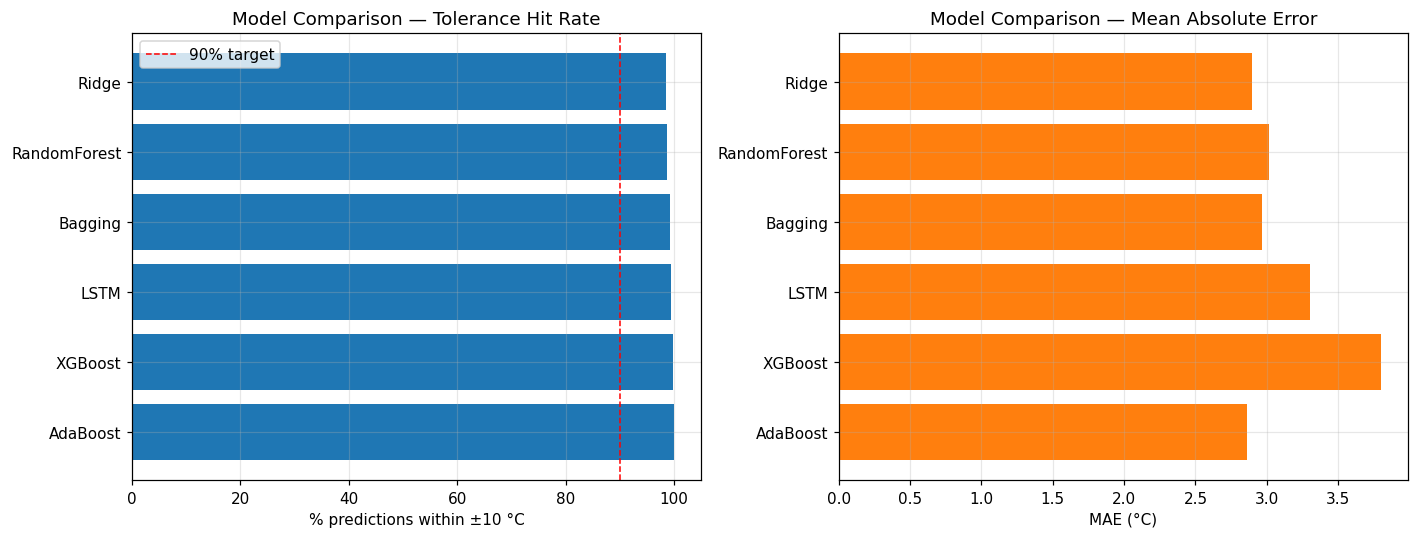

Best model: AdaBoost


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(results_df['model'], results_df['within_10C_%'], color='tab:blue')
axes[0].axvline(90, color='red', ls='--', lw=1, label='90% target')
axes[0].set_xlabel('% predictions within ±10 °C')
axes[0].set_title('Model Comparison — Tolerance Hit Rate')
axes[0].legend()

axes[1].barh(results_df['model'], results_df['MAE'], color='tab:orange')
axes[1].set_xlabel('MAE (°C)')
axes[1].set_title('Model Comparison — Mean Absolute Error')

plt.tight_layout()
plt.savefig(FIG_DIR / 'model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

best_name = results_df.iloc[0]['model']
print('Best model:', best_name)

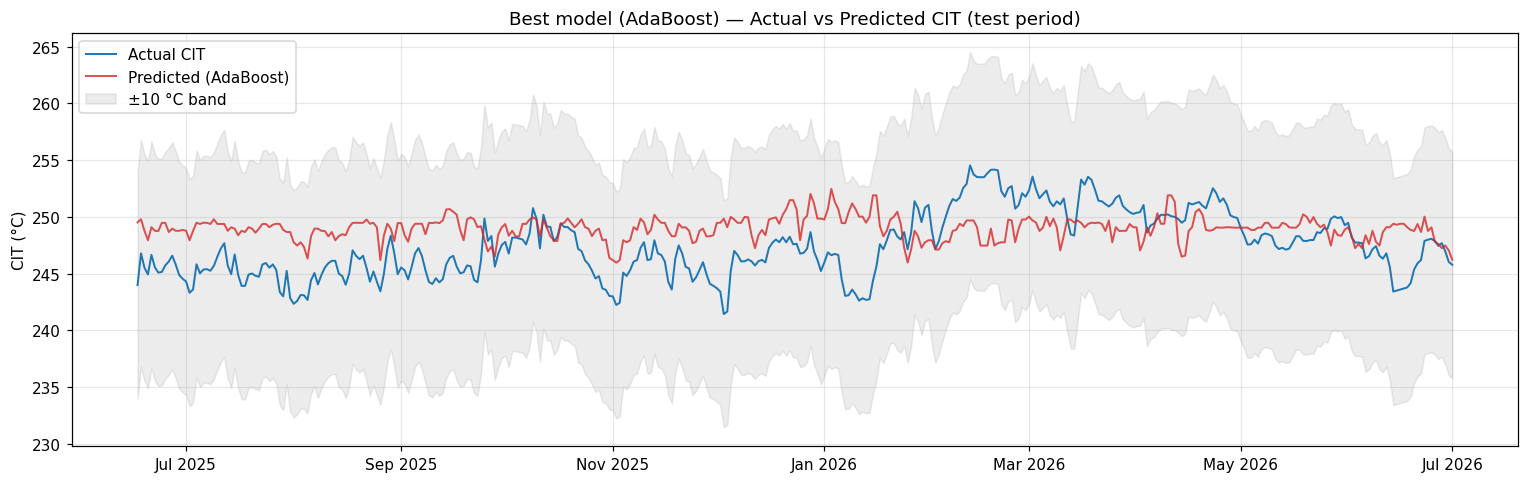

In [25]:
best_pred  = pred_lstm      if best_name == 'LSTM' else predictions[best_name]
best_true  = y_test_lstm    if best_name == 'LSTM' else y_test.values
best_dates = X_test.index[ENROL:] if best_name == 'LSTM' else X_test.index

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(best_dates, best_true,  lw=1.3, color='tab:blue',   label='Actual CIT')
ax.plot(best_dates, best_pred,  lw=1.3, color='tab:red', alpha=0.8,
        label=f'Predicted ({best_name})')
ax.fill_between(best_dates, best_true - 10, best_true + 10,
                color='gray', alpha=0.15, label='±10 °C band')
ax.set_ylabel('CIT (°C)')
ax.set_title(f'Best model ({best_name}) — Actual vs Predicted CIT (test period)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_model_actual_vs_predicted.png', dpi=110, bbox_inches='tight')
plt.show()

In [26]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
    m = RandomForestRegressor(n_estimators=300, random_state=42)
    m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = m.predict(X.iloc[te_idx])
    cv_rows.append({
        'fold'        : fold,
        'test_start'  : X.index[te_idx[0]].date(),
        'test_end'    : X.index[te_idx[-1]].date(),
        'R2'          : round(r2_score(y.iloc[te_idx], pred), 3),
        'within_10C_%': round((np.abs(pred - y.iloc[te_idx].values) <= 10).mean() * 100, 1),
    })

print('Time-series cross-validation (Random Forest):')
pd.DataFrame(cv_rows)

Time-series cross-validation (Random Forest):


,fold,test_start,test_end,R2,within_10C_%
0,1,2022-01-15,2022-11-26,-0.130,100.0
1,2,2022-11-27,2023-10-08,-0.289,97.8
2,3,2023-10-09,2024-10-07,-0.350,59.2
3,4,2024-10-08,2025-08-19,-0.698,93.4
4,5,2025-08-20,2026-07-01,-0.233,100.0


## 10. HX Importance Ranking (Feature Importance → CIT)

Aggregate feature importances from the best tree-based model, summed per HX
across its `Q_norm`, `dT_cold`, `duty_kW`, and `dT_hot` features.

This ranks **which HX's thermal state most strongly drives CIT**.

In [27]:
tree_models = {k: v for k, v in fitted.items()
               if hasattr(v, 'feature_importances_')}
importance_source = max(
    tree_models,
    key=lambda k: results_df.set_index('model').loc[k, 'within_10C_%']
)
importances = pd.Series(
    fitted[importance_source].feature_importances_, index=X.columns
).sort_values(ascending=False)

print(f'Using {importance_source} feature importances')
print('Top 15 features:')
importances.head(15)

Using AdaBoost feature importances
Top 15 features:


E106AB_dT_hot     0.145660
E103AB_dT_hot     0.109877
flue_O2           0.109249
E113A_cold_in     0.102054
E102_dT_hot       0.098560
E101AB_dT_hot     0.047547
E105AB_dT_cold    0.046288
E107AB_dT_hot     0.031662
E110ABC_dT_hot    0.031473
E111_dT_hot       0.025144
E101AB_Q_norm     0.024696
E104_Q_norm       0.020334
E106AB_dT_cold    0.017159
E106AB_duty_kW    0.016297
E112AB_dT_hot     0.012968
dtype: float64

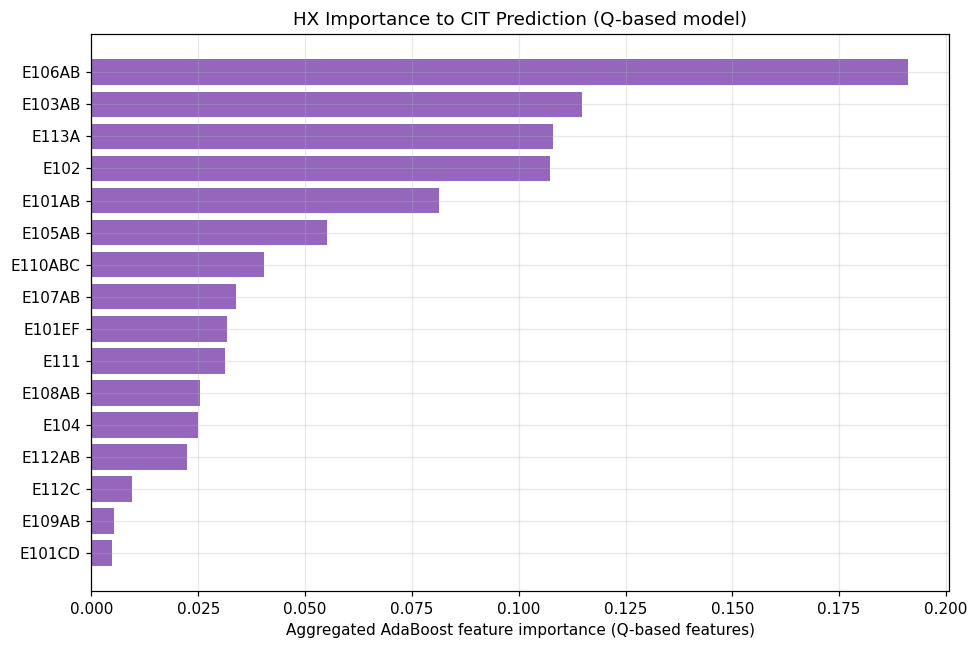

E106AB     0.191137
E103AB     0.114738
E113A      0.108107
E102       0.107354
E101AB     0.081382
E105AB     0.055076
E110ABC    0.040343
E107AB     0.033919
E101EF     0.031820
E111       0.031222
E108AB     0.025306
E104       0.025044
E112AB     0.022414
E112C      0.009485
E109AB     0.005263
E101CD     0.004726
dtype: float64

In [28]:
hx_importance = {}
for hx in HX_CONFIG.keys():
    cols = [c for c in X.columns if c.startswith(hx + '_')]
    if cols:
        hx_importance[hx] = importances[cols].sum()

hx_importance_s = pd.Series(hx_importance).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(hx_importance_s.index, hx_importance_s.values, color='tab:purple')
ax.set_xlabel(f'Aggregated {importance_source} feature importance (Q-based features)')
ax.set_title('HX Importance to CIT Prediction (Q-based model)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'hx_Q_importance_ranking.png', dpi=110, bbox_inches='tight')
plt.show()

hx_importance_s

## 11. Combined Cleaning-Priority Table

Three signals are combined into one priority score:

1. **Q fouling rate** — how fast the duty is declining (|slope|)
2. **CIT importance** — how much this HX's Q drives the CIT prediction model
3. **Q-CIT correlation** — direct Pearson r (Q_norm vs CIT)

Each is min-max normalised to [0,1] and averaged (equal weight). The higher
the combined score, the more this HX costs in CIT when it fouls — and the more
CIT it should recover when cleaned.

**Expected CIT gain per clean** (indicative): using the regression slopes
from Section 6, the expected Q recovery × the Q-CIT slope gives a rough
estimate of how many °C CIT would rise if the HX were cleaned to baseline.

In [29]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0, index=s.index)

# Build aligned index on fouling_rank HX list
fr_set  = fouling_rank.set_index('HX')
hx_list = fr_set.index.tolist()

fr_abs  = fr_set['median_Q_slope'].abs()
ci      = hx_importance_s.reindex(hx_list).fillna(0)
qcit    = corr_df.set_index('HX')['Q_CIT_corr'].reindex(hx_list).fillna(0).clip(lower=0)

priority_score = (minmax(fr_abs) + minmax(ci) + minmax(qcit)) / 3

# Expected CIT gain: Q_baseline_drop × slope(Q→CIT)
expected_cit_gain = {}
for hx in hx_list:
    if hx not in corr_df.set_index('HX').index:
        expected_cit_gain[hx] = np.nan
        continue
    joint = pd.concat([Q_norm_df[hx].rename('Q'), cit.rename('CIT')], axis=1).dropna()
    if len(joint) < 30:
        expected_cit_gain[hx] = np.nan
        continue
    m, _ = np.polyfit(joint['Q'], joint['CIT'], 1)
    # Q gain when cleaned to baseline
    reco_hx = cleaning_reco.set_index('HX')
    if hx in reco_hx.index:
        q_drop = reco_hx.loc[hx, 'baseline_Q_norm'] - reco_hx.loc[hx, 'current_Q_norm']
        expected_cit_gain[hx] = round(m * q_drop, 2)
    else:
        expected_cit_gain[hx] = np.nan

priority = pd.DataFrame({
    'Q_fouling_rate_abs'  : fr_abs,
    'cit_model_importance': ci,
    'Q_CIT_correlation'   : qcit,
    'priority_score'      : priority_score,
    'expected_CIT_gain_C' : pd.Series(expected_cit_gain),
}).sort_values('priority_score', ascending=False)

reco_join = cleaning_reco.set_index('HX')[['recommended_action', 'Q_drop_%']]
priority  = priority.join(reco_join)

priority.to_csv(OUT_DIR / 'hx_Q_cleaning_priority.csv')
print('Saved → ', OUT_DIR / 'hx_Q_cleaning_priority.csv')
priority.round(4)

Saved →  C:\Desktop\Bangchak Internship 2026\furnace-optimization\outputs\hx_Q_cleaning_priority.csv


,Q_fouling_rate_abs,cit_model_importance,Q_CIT_correlation,priority_score,expected_CIT_gain_C,recommended_action,Q_drop_%
E113A,0.1499,0.1081,0.0000,0.5182,-0.65,Clean now (past trigger),82.3
E106AB,0.0018,0.1911,0.1457,0.4564,0.03,Stable / long horizon (>3y),2.0
E105AB,0.0048,0.0551,0.4066,0.4337,-0.34,Stable / monitor,-1.6
E101AB,0.0110,0.0814,0.2858,0.3955,3.11,Clean now (past trigger),30.2
E103AB,0.0164,0.1147,0.0982,0.3134,0.23,Clean now (past trigger),21.7
E101CD,0.0058,0.0047,0.3290,0.2824,-0.31,Stable / monitor,-3.5
E110ABC,0.0146,0.0403,0.2273,0.2823,0.93,Clean now (past trigger),32.7
E102,0.0051,0.1074,0.0577,0.2419,0.51,Clean now (past trigger),38.3
E108AB,0.0043,0.0253,0.1297,0.1523,0.41,Clean now (past trigger),31.8
E104,0.0001,0.0250,0.0821,0.1036,1.03,Clean now (past trigger),27.2


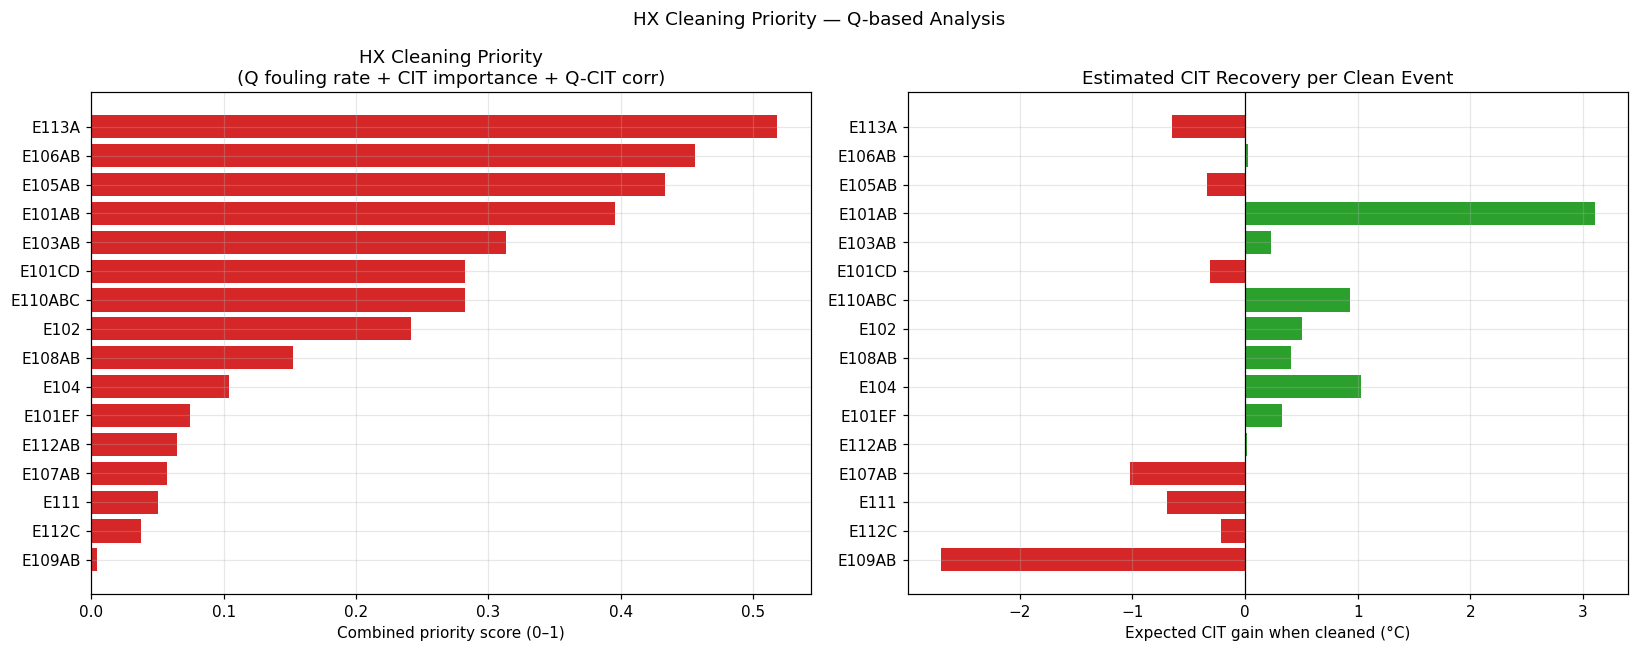

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: combined priority score
axes[0].barh(priority.index, priority['priority_score'], color='tab:red')
axes[0].set_xlabel('Combined priority score (0–1)')
axes[0].set_title('HX Cleaning Priority\n(Q fouling rate + CIT importance + Q-CIT corr)')
axes[0].invert_yaxis()

# Right: expected CIT gain
exp_gain = priority['expected_CIT_gain_C'].dropna()
bar_c2 = ['tab:green' if v > 0 else 'tab:red' for v in exp_gain]
axes[1].barh(exp_gain.index, exp_gain.values, color=bar_c2)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Expected CIT gain when cleaned (°C)')
axes[1].set_title('Estimated CIT Recovery per Clean Event')
axes[1].invert_yaxis()

plt.suptitle('HX Cleaning Priority — Q-based Analysis', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hx_Q_cleaning_priority.png', dpi=110, bbox_inches='tight')
plt.show()

In [31]:
print('='*65)
print('TOP CLEANING RECOMMENDATIONS (Q-based priority)')
print('='*65)
top3 = priority[priority['Q_drop_%'] > 0].head(5)
for rank, (hx, row) in enumerate(top3.iterrows(), 1):
    cit_str = (f'+{row["expected_CIT_gain_C"]:.1f} °C CIT'
               if pd.notna(row['expected_CIT_gain_C']) else 'CIT gain N/A')
    print(f'  #{rank}  {hx:<10}  Q drop={row["Q_drop_%"]:>5.1f}%  '
          f'Priority={row["priority_score"]:.3f}  '
          f'Est. {cit_str}  Action: {row["recommended_action"]}')
print('='*65)

TOP CLEANING RECOMMENDATIONS (Q-based priority)
  #1  E113A       Q drop= 82.3%  Priority=0.518  Est. +-0.7 °C CIT  Action: Clean now (past trigger)
  #2  E106AB      Q drop=  2.0%  Priority=0.456  Est. +0.0 °C CIT  Action: Stable / long horizon (>3y)
  #3  E101AB      Q drop= 30.2%  Priority=0.395  Est. +3.1 °C CIT  Action: Clean now (past trigger)
  #4  E103AB      Q drop= 21.7%  Priority=0.313  Est. +0.2 °C CIT  Action: Clean now (past trigger)
  #5  E110ABC     Q drop= 32.7%  Priority=0.282  Est. +0.9 °C CIT  Action: Clean now (past trigger)


## 12. Summary & Limitations

**What this notebook delivers (vs previous eps-based version):**
- Crude temperature sensor outliers detected (rolling z-score, 30-day window)
  and replaced with rolling mean before any feature calculation
- Q duty (cold-side only) used as the **primary fouling indicator** — no hot-side data required
- Q normalised by total charge rate removes bulk throughput variation
- Campaign detection, fouling-rate ranking, and cleaning trigger all based on Q
- Q–CIT correlation analysis quantifies which HX is most critical to furnace feed temperature
- Expected CIT gain per cleaning event estimated from Q-drop × Q→CIT regression slope
- Combined priority score (Q fouling rate + CIT model importance + Q-CIT correlation) ranks
  which HX is most worth cleaning first

**Known limitations:**
- Q is still influenced by crude inlet temperature (which varies seasonally and from
  upstream operations). The charge-normalisation removes flow effects but not inlet-T effects.
  A more robust metric requires hot-side data — this approach accepts that trade-off in exchange
  for using only reliable cold-side sensor readings.
- `cp = 2.2 kJ/kg·K`, `rho = 850 kg/m³` are assumed constants. Actual crude assay values
  should be substituted when available to improve Q accuracy.
- Cleaning events are **inferred** (no maintenance log). Engineer confirmation of inferred
  campaign boundaries is recommended before scheduling actual cleaning.
- Expected CIT gain is a linear estimate; actual plant response depends on concurrent
  changes in other HX, crude slate, and furnace operation.
- Economic cleaning point (optimal CPI) requires cleaning cost and fuel-price data,
  which are not yet available in this dataset.